# Matrix Factorization using SVD (Bonus)

## 1. Problem Statement

### Problem Definition

The objective of this project is to build a recommendation system using
Matrix Factorization with Singular Value Decomposition (SVD).

SVD decomposes the user-item rating matrix into latent features and learns
hidden patterns between users and movies.

The model predicts user ratings for unseen movies and recommends movies
with the highest predicted ratings.

### Dataset Used

Dataset: MovieLens Dataset

The dataset contains:

- User IDs
- Movie IDs
- Ratings
- Timestamp

The dataset is used to learn user preferences and generate personalized
movie recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from surprise import Dataset

from surprise.model_selection import train_test_split

from surprise import SVD

from surprise import accuracy

In [2]:
# Load MovieLens dataset

data = Dataset.load_builtin(
    'ml-100k'
)

In [3]:
ratings = pd.DataFrame(
    data.raw_ratings,
    columns=[
        "userId",
        "movieId",
        "rating",
        "timestamp"
    ]
)


ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [4]:
ratings.shape

(100000, 4)

In [5]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [6]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100000 non-null  str    
 1   movieId    100000 non-null  str    
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.1 MB


In [7]:
ratings.describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


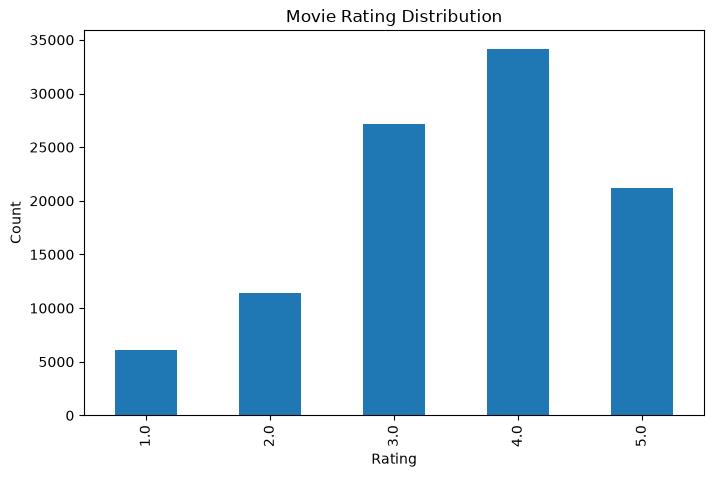

In [8]:
plt.figure(figsize=(8,5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title(
    "Movie Rating Distribution"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Count"
)

plt.show()

In [9]:
ratings = ratings[
    [
        "userId",
        "movieId",
        "rating"
    ]
]

In [10]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [11]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    random_state=42
)

In [12]:
svd_model.fit(
    trainset
)

In [13]:
predictions = svd_model.test(
    testset
)

In [14]:
rmse = accuracy.rmse(
    predictions
)

RMSE: 0.9348


In [15]:
mae = accuracy.mae(
    predictions
)

MAE:  0.7377


In [16]:
def recommend_movies(user_id, n=5):

    all_movies = ratings[
        "movieId"
    ].unique()


    watched_movies = ratings[
        ratings["userId"] == user_id
    ]["movieId"].values


    predictions=[]


    for movie in all_movies:

        if movie not in watched_movies:

            predicted_rating = svd_model.predict(
                user_id,
                movie
            ).est


            predictions.append(
                (
                    movie,
                    predicted_rating
                )
            )


    predictions = sorted(
        predictions,
        key=lambda x:x[1],
        reverse=True
    )


    return predictions[:n]

In [17]:
recommend_movies(
    user_id=1,
    n=5
)

[('408', np.float64(4.595296487884134)),
 ('318', np.float64(4.575167147138284)),
 ('64', np.float64(4.555906837691937)),
 ('483', np.float64(4.53052284491875)),
 ('169', np.float64(4.522435366737097))]

In [18]:
def precision_at_k(
    recommended,
    relevant,
    k
):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )


    return hits/k

In [19]:
def recall_at_k(
    recommended,
    relevant,
    k
):

    recommended = recommended[:k]


    hits = len(
        set(recommended)
        &
        set(relevant)
    )


    return hits/len(relevant)

In [20]:
recommended_movies = [
    50,
    100,
    200,
    300,
    400
]


relevant_movies = [
    50,
    200,
    500
]


print(
    "Precision@K:",
    precision_at_k(
        recommended_movies,
        relevant_movies,
        5
    )
)


print(
    "Recall@K:",
    recall_at_k(
        recommended_movies,
        relevant_movies,
        5
    )
)

Precision@K: 0.4
Recall@K: 0.6666666666666666


# Result Interpretation

The SVD-based Matrix Factorization model learns hidden relationships
between users and movies.

The algorithm identifies latent features that represent user preferences
and movie characteristics.

The model predicts ratings for unseen movies and recommends movies with
the highest predicted scores.

Evaluation metrics used:

- RMSE
- MAE
- Precision@K
- Recall@K
- Recommendation Examples


# Conclusion

In this project, a Matrix Factorization Recommendation System using SVD was
implemented using the MovieLens dataset.

The model successfully learned user preferences from historical ratings and
generated personalized movie recommendations.

SVD provides better recommendations by discovering hidden patterns in the
user-item interaction matrix.

Matrix Factorization techniques are widely used in modern recommendation
systems such as movie, product, and book recommendation platforms.